# 1. Signal Extraction
In the first step, we extract three types of point-based signals: edge/bulk points, inside/outside points, and physics loss collocation points. These points serve as inputs for the phase-field optimization. The smoothing loss collocation points will be extracted after the second stage of optimization, which is demonstrated in the second notebook.

##### Input:
- `dat/{shape}.tif`  (tif image)

##### Output:
- `dat/pt_e_{shape}.npz` (edge/bulk points)
- `dat/pt_s_{shape}.npz` (inside/outside points)
- `dat/pt_p_{shape}.npz` (physics collocation points)

In [3]:
import sys
import os
import numpy as np
from pathlib import Path

#### Add program source to sys.path ####
project_root = Path().resolve()
sys.path.append(str(project_root / "../../src"))

#### Dataset
For this tutorial, we use a FIB-SEM dataset from the Janelia database (https://openorganelle.janelia.org/datasets/jrc_cos7-1b). An endocytic pit is extracted with coordinates $x: (2472, 2509)$, $y: (862, 899)$, and $z: (125, 146)$ in the s2 coordinate system, and saved as `dat/{shape}.tif`. This volume is used as the input for the entire workflow.

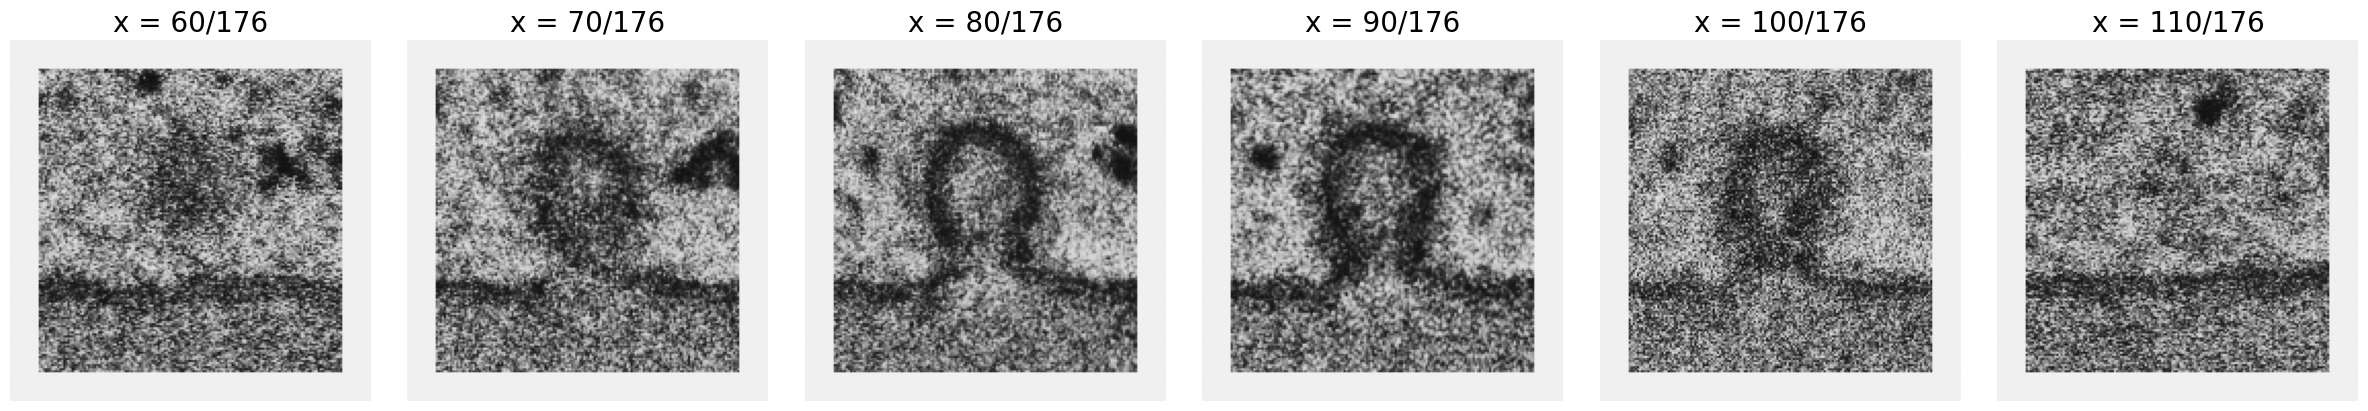

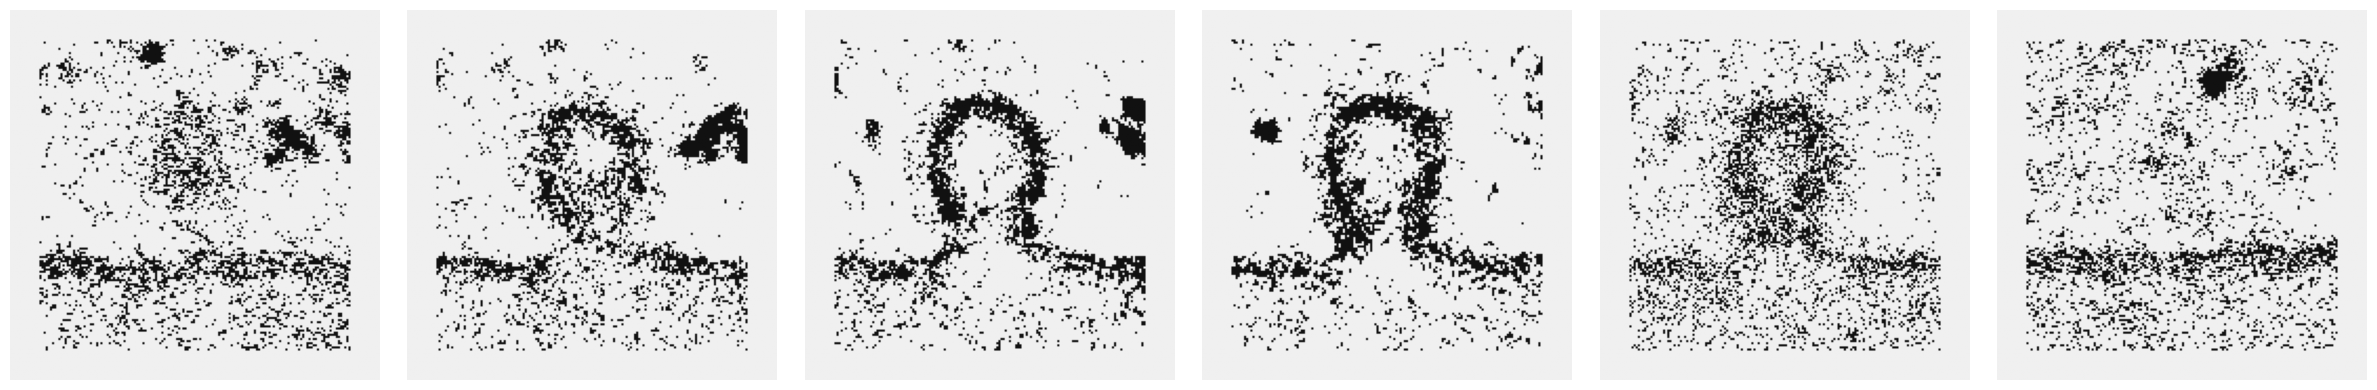

In [4]:
import tifffile as tiff
from data_generation.preprocess import overlay_points_on_cryoet

#### Import tiff file ####
my_data_path = "../dat"
shape = "bud-11"
file_name = f"{shape}.tif"
file_path = os.path.join(my_data_path, file_name)
cryoet = tiff.imread(file_path)
cryoet = cryoet / cryoet.max()
cryoet = 1 - cryoet

#### Visualize data ####
slices = range(60, 120, 10)
visualize = cryoet
overlay_points_on_cryoet(visualize, axis='x', slice_index=slices, show_title=True)
overlay_points_on_cryoet(visualize, axis='x', slice_index=slices, threshold=0.75)

#### Extract edge/bulk signal
In this tutorial, we extract edge and bulk signals using a simple thresholding method. We sample edge points above the threshold and bulk points below it. For practical applications, this step can also be performed using semantic segmentation methods (e.g., MemBrain-seg).

edge size:  54518.0
bulk size:  109036.0


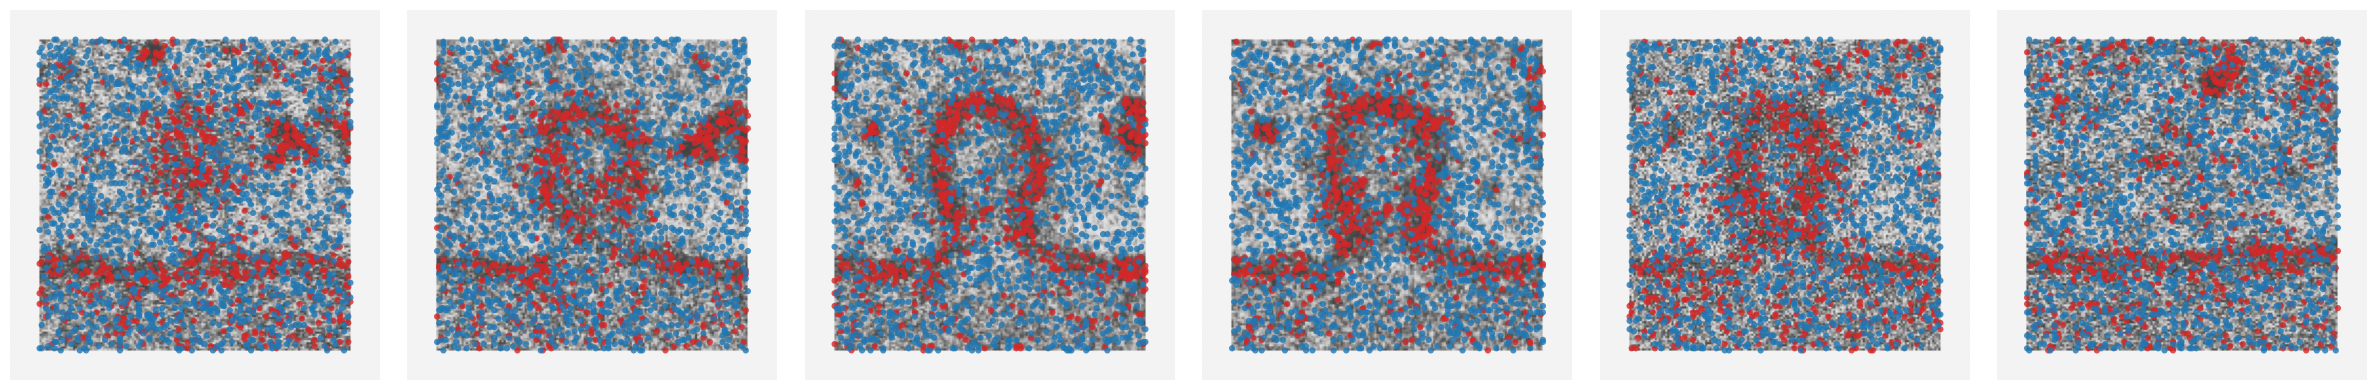

In [8]:
from data_generation.preprocess import downsample_binary_mask_to_fraction, overlay_points_on_cryoet, build_data_edge_from_masks
from pinn.utils import save_pts_data, load_pts_data

#### Parameters ####
threshold = 0.75
target_edge = 0.01
target_bulk = 0.02

#### Sample edge/bulk signals ####
GRID_SIZE = cryoet.shape[2]
z, y, x = np.indices(cryoet.shape)
mask = ((x >= 14) & (x < 162) & (y >= 14) & (y < 162) & (z >= 46) & (z < 130))
edge = (cryoet > threshold)
bulk = (~edge) & mask
edge = downsample_binary_mask_to_fraction(edge, target_frac=target_edge, seed=0)
bulk = downsample_binary_mask_to_fraction(bulk, target_frac=target_bulk, seed=0)
edge = edge.astype(np.float32)
bulk = bulk.astype(np.float32)
print("edge size: ", edge.sum())
print("bulk size: ", bulk.sum())

#### Save point data ####
data_edge = build_data_edge_from_masks(edge=edge, bulk=bulk, volume_shape=cryoet.shape)
meta_data ={
    "type": "edge",
    "label_meaning": {1: "edge", 0: "bulk"},
    "GRID_SIZE": GRID_SIZE,
    "edge_min": threshold,
    "target_edge": target_edge,
    "target_bulk": target_bulk,
    "shape": shape,
}
save_pts_data(data_edge, f"../dat/pt_e_{shape}.npz", meta_data)

#### Visualize data ####
slices = range(60, 120, 10)
data = load_pts_data(f"../dat/pt_e_{shape}.npz", perm=(2,1,0))
edge = data["points"][data["label"] == 1]
bulk = data["points"][data["label"] == 0]
overlays = [
    {"data": edge, "label": "Edge", "color": "tab:red"},
    {"data": bulk, "label": "Bulk", "color": "tab:blue"},
]
overlay_points_on_cryoet(cryoet=cryoet, overlays=overlays, axis='x', slice_index=slices, cryo_alpha=0.8, show_title=True)


#### Extract inside/outside signal
In this tutorial, we manually sample the inside and outside signals using napari extension. An example set of sampled points is provided in pt_s_bud-11.npz.

In [5]:
# from data_generation.preprocess import napari_sign_labeler

#### Manually sample points and save data ####
## It should be done at local machine since it uses graphic user interface 
# %gui qt
# save_path = f"../dat/pt_s_{shape}.npz"
# viewer, pts_plus, pts_minus = napari_sign_labeler(normalized, save_path=save_path, size=5)

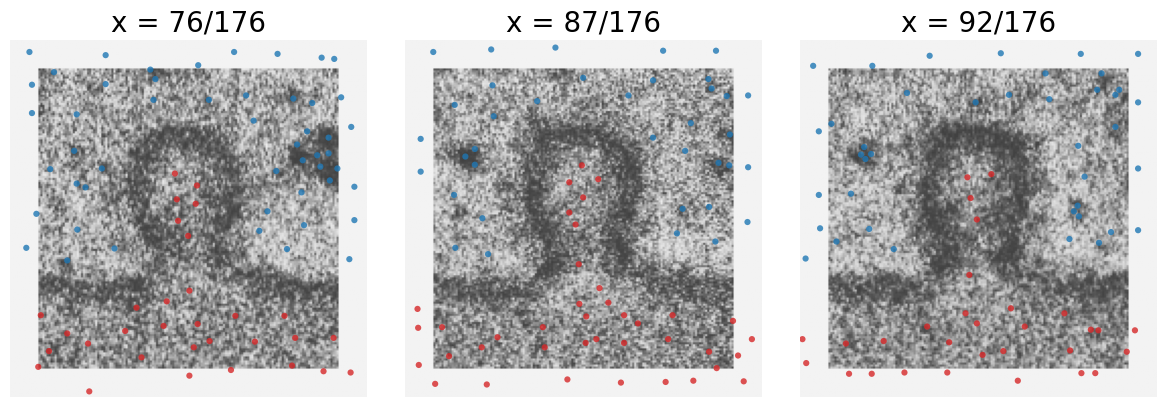

In [18]:
from pinn.utils import load_pts_data
from data_generation.preprocess import overlay_points_on_cryoet

#### Visualize data ####
sign = load_pts_data(f"../dat/pt_s_{shape}.npz", perm=(2,1,0))
inside  = sign["points"][sign["label"] == 1]
outside = sign["points"][sign["label"] == -1]
overlays = [
    {"data": inside,  "label": "Inside",  "color": "tab:red"},
    {"data": outside, "label": "Outside", "color": "tab:blue"},
]
slices = [76, 87, 92]

overlay_points_on_cryoet(cryoet=cryoet, overlays=overlays, axis='x', slice_index=slices, cryo_alpha=0.8, show_title=True)

#### Extract physics collocatioin points ####
Collocation points are used to evaluate the physics loss. We sample these points randomly within the simulation box.

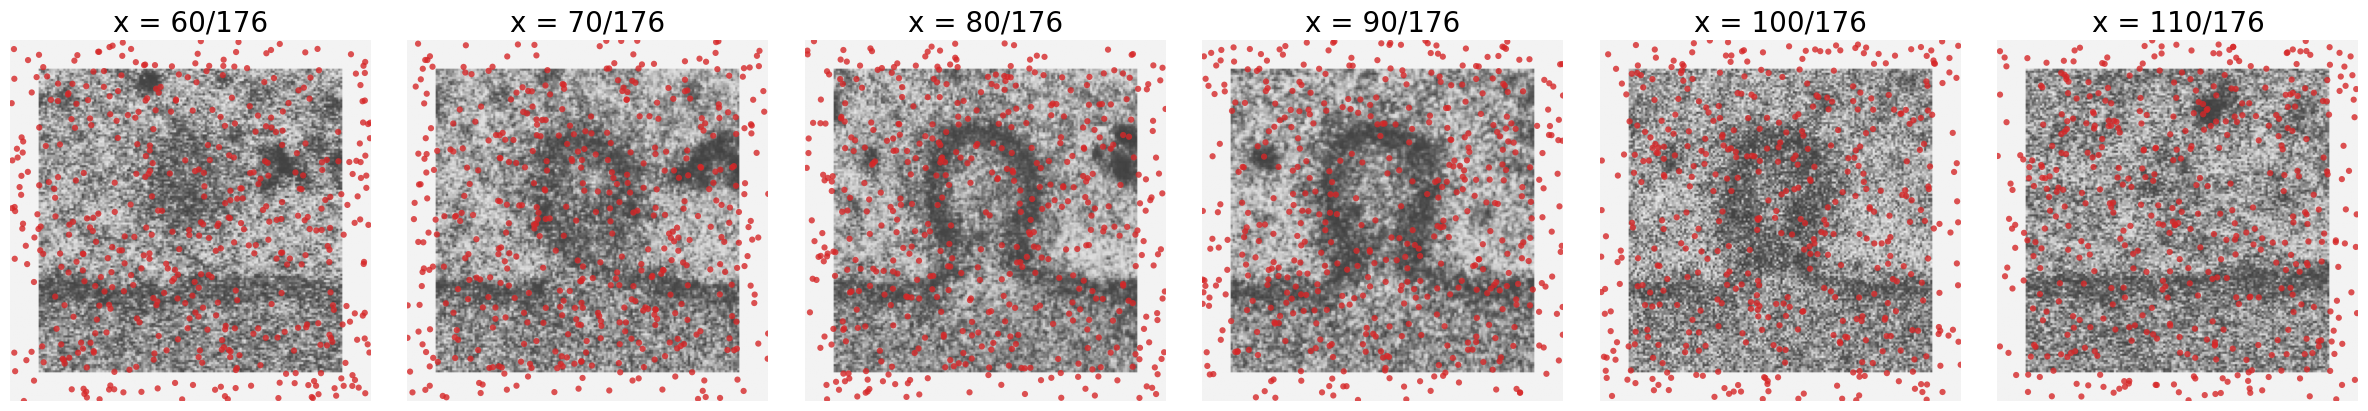

In [24]:
import jax

#### Randomly sample collocation points ####
seed = 0
key = jax.random.PRNGKey(seed)
num_collocation = 80000
x_train = (jax.random.uniform(key, (num_collocation, 3), minval=-1, maxval=1))
data_phys = {"points": x_train}
meta_phys = {
    "type": "phys",
    "n_sample": num_collocation,
    "seed": seed,
    "sampling": "random",
}

#### Save data ####
save_pts_data(data_phys, f"../dat/pt_p_{shape}.npz", meta_phys)

#### Visualize data ####
slices = range(60, 120, 10)
data = load_pts_data(f"../dat/pt_p_{shape}.npz", perm=(2,1,0))
phys = data["points"]
overlays = [
    {"data": phys, "label": "Physics", "color": "tab:red"},
]
overlay_points_on_cryoet(cryoet=cryoet, overlays=overlays, axis='x', slice_index=slices, cryo_alpha=0.8, show_title=True)